# Logistic Regression — Phân loại khu vực cao điểm (New York City)

**Dữ liệu:** `dataclean/citibike_nyc_cleaned.parquet` · Kỳ **04/2025 – 04/2026**

**Hệ thống:** Citi Bike (NYC)

> **Dự đoán liệu một khu vực (`area_id`) trong một giờ nhất định có rơi vào trạng thái cao điểm (`rush area`) hay không.**

| Nhãn | Ý nghĩa |
|---|---|
| `0` | Khu vực không ở trạng thái cao điểm |
| `1` | Khu vực ở trạng thái cao điểm |


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.rush_area_model as rush_area_model
importlib.reload(rush_area_model)

from src.rush_area_model import (
    build_rush_area_dataset,
    split_summary_table,
    panel_summary_table,
    area_summary_table,
    train_logistic_rush_area_model,
    metrics_table,
    plot_logistic_metrics,
    plot_confusion_matrix,
    plot_area_folium,
    choose_snapshot_hour,
    plot_rush_probability_map,
    show_top_rush_probabilities,
    TOP_AREAS,
    RUSH_QUANTILE,
    MIN_RUSH_THRESHOLD,
)

CLEAN_FILE = "citibike_nyc_cleaned.parquet"
SYSTEM_NAME = "Citi Bike (NYC)"
CITY_NAME = "New York City"
DATA_PATH = Path(project_root) / "dataclean" / CLEAN_FILE

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Chưa có {DATA_PATH}. Chạy scripts/run_clean_all.py trước.")


## Khối 1 · Đơn vị quan sát và `area_id`

### 1. Đơn vị quan sát

Mỗi quan sát ứng với một cặp khu vực - thời điểm theo giờ:

$$
(a, t),\quad a \in \mathcal{A},\; t \in \mathcal{T}
$$

Biến đếm nhu cầu:

$$
\mathrm{demand\_count}(a,t)=\#\{\text{chuyến bắt đầu trong khu vực } a \text{ ở giờ } t\}
$$

Diễn giải:
1. Chia dữ liệu theo từng giờ `timestamp_hour`.
2. Trong mỗi giờ, đếm số chuyến theo từng `area_id`.
3. Mỗi dòng trong panel là một giá trị `demand_count(a,t)`.

### 2. Định nghĩa `area_id`

Khu vực được tạo bằng ô lưới tọa độ 0.01° × 0.01°:

$$
\mathrm{area\_lat}=\frac{\lfloor 100\cdot \mathrm{start\_lat}\rfloor}{100},\qquad
\mathrm{area\_lng}=\frac{\lfloor 100\cdot \mathrm{start\_lng}\rfloor}{100}
$$

$$
\mathrm{area\_id}=\text{concat}(\mathrm{area\_lat},\;\_\;,\mathrm{area\_lng})
$$

Diễn giải:
1. Làm tròn xuống theo bậc 0.01 cho vĩ độ và kinh độ.
2. Ghép cặp `(area_lat, area_lng)` thành mã vùng `area_id`.
3. Mỗi `area_id` đại diện cho một ô lưới không gian cố định.

Notebook giữ **150 khu vực** có tổng chuyến cao nhất (`TOP_AREAS = 150`).

### 3. Đặc trưng

| Nhóm | Biến |
|---|---|
| Không gian | `area_id` |
| Thời gian | `hour_of_day`, `day_of_week`, `month_of_year`, `is_weekend` |
| Biến trễ | `lag_1`, `lag_2`, `lag_24`, `lag_168` |


## Khối 2 · Tạo panel `area × hour` và gán nhãn rush

### 1. Quy trình tạo dữ liệu mô hình
Quy trình:

1. Gom `demand_count` theo `area_id × timestamp_hour`.
2. Chọn top 150 khu vực hoạt động mạnh nhất.
3. Tạo panel đầy đủ `hour × area`, thiếu thì điền `0`.
4. Tạo lag `1, 2, 24, 168` giờ.
5. Chia train/test theo thời gian: **80% đầu / 20% cuối**.
6. Gán nhãn rush theo ngưỡng riêng từng khu vực trên tập train.

Công thức ngưỡng:

$$
\mathrm{rush\_threshold}(a)=\max\left(Q_{0.90}\left(\{\mathrm{demand\_count}(a,t): t\in \mathcal{T}_{\text{train}}\}\right),\;3\right)
$$

Công thức gán nhãn:

$$
\mathrm{is\_rush\_area}(a,t)=
\begin{cases}
1, & \mathrm{demand\_count}(a,t)\ge \mathrm{rush\_threshold}(a)\\
0, & \text{ngược lại}
\end{cases}
$$

Diễn giải:
1. Với mỗi khu vực `a`, lấy phân vị 90% của nhu cầu trên train.
2. Chặn dưới ngưỡng ở mức 3 chuyến/giờ để tránh ngưỡng quá thấp.
3. So sánh `demand_count(a,t)` với ngưỡng để gán nhãn `0/1`.

### 2. Train/test theo thời gian
Đây là dữ liệu time series dạng panel, nên notebook **không chia random**. Sau khi tạo xong lag:

$$
\mathcal{T}=\mathcal{T}_{\text{train}}\cup\mathcal{T}_{\text{test}},\quad
\mathcal{T}_{\text{train}}\cap\mathcal{T}_{\text{test}}=\varnothing
$$

$$
\lvert \mathcal{T}_{\text{train}}\rvert \approx 0.8\lvert\mathcal{T}\rvert,\qquad
\lvert \mathcal{T}_{\text{test}}\rvert \approx 0.2\lvert\mathcal{T}\rvert
$$

Theo thứ tự thời gian: 80% đầu làm train, 20% cuối làm test.

Tập **train** dùng để:
- học Logistic Regression;
- tính `rush_threshold` theo P90 của từng khu vực.

Tập **test** dùng để:
- mô phỏng giai đoạn tương lai mà mô hình chưa thấy;
- đánh giá metric và thử các giờ cụ thể như `DEMO_HOUR`.

Vì vậy khi tự chọn một giờ để kiểm thử, giờ đó nên nằm trong khoảng `test` được in ra ở bảng `split_summary_table`.


In [2]:
RUSH_LABELED = build_rush_area_dataset(
    DATA_PATH,
    SYSTEM_NAME,
    city_name=CITY_NAME,
    top_areas=TOP_AREAS,
    rush_quantile=RUSH_QUANTILE,
    min_threshold=MIN_RUSH_THRESHOLD,
)

RUSH_LABELED["data"].head()


Loading cleaned data from /opt/project/dataclean/citibike_nyc_cleaned.parquet...
Dataset generated. Rows: 1320900, Areas: 150


,timestamp_hour,area_id,demand_count,hour_of_day,day_of_week,month_of_year,is_weekend,lag_1,lag_2,lag_24,lag_168,split,rush_threshold,is_rush_area
0,2023-12-31 02:00:00,40.64_-73.97,0,2,Sunday,12,1,0,0,0,0,train,17.0,0
1,2023-12-31 03:00:00,40.64_-73.97,0,3,Sunday,12,1,0,0,0,0,train,17.0,0
2,2023-12-31 04:00:00,40.64_-73.97,0,4,Sunday,12,1,0,0,0,0,train,17.0,0
3,2023-12-31 05:00:00,40.64_-73.97,0,5,Sunday,12,1,0,0,0,0,train,17.0,0
4,2023-12-31 06:00:00,40.64_-73.97,0,6,Sunday,12,1,0,0,0,0,train,17.0,0


## Khối 3 · Kiểm tra panel, khoảng train/test và bản đồ `area_id`

Bảng `split_summary_table` trả lời trực tiếp:

```text
Mô hình train từ giờ nào đến giờ nào?
Khi kiểm thử được phép chọn DEMO_HOUR trong khoảng nào?
```

Sau đó `panel_summary_table` cho biết số khu vực, tỷ lệ rush và ngưỡng trung vị. Bản đồ polygon minh họa `area_id` theo tổng nhu cầu.


In [3]:
display(split_summary_table(RUSH_LABELED))
display(panel_summary_table(RUSH_LABELED))
display(area_summary_table(RUSH_LABELED, top_n=10))


,Split,Start Time,End Time,Total Rows
0,Train,2023-12-31 02:00:00,2024-10-19 13:00:00,1056600
1,Test,2024-10-19 14:00:00,2024-12-31 23:00:00,264300


,Metric,Value
0,Number of Areas,150
1,Total Rows in Panel,1320900
2,Rush Labeled Rows,131899 (9.99%)
3,Median Rush Threshold,40.0


,area_id,total_demand,rush_threshold,rush_hours
56,40.72_-73.99,1485981,354.0,851
63,40.73_-74.0,1385288,342.0,887
57,40.72_-74.0,1227667,316.0,875
64,40.73_-74.01,1134417,297.0,824
62,40.73_-73.99,1095878,259.0,874
73,40.74_-73.99,1042708,256.0,875
75,40.74_-74.01,1021674,277.0,833
95,40.76_-73.99,996878,242.7,877
86,40.75_-74.0,985866,224.0,874
84,40.75_-73.98,958127,254.0,862


In [4]:
plot_area_folium(RUSH_LABELED, metric="total_demand")


## Khối 4 · Logistic Regression

Bài toán phân loại nhị phân:

$$
y=\mathrm{is\_rush\_area}\in\{0,1\}
$$

$$
z=\beta_0+\sum_{j=1}^{p}\beta_j x_j
$$

$$
\hat{p}(y=1\mid X)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

Quy tắc phân lớp:

$$
\hat{y}=
\begin{cases}
1, & \hat{p}\ge 0.5\\
0, & \hat{p}<0.5
\end{cases}
$$

Diễn giải step-by-step:
1. Từ đặc trưng đầu vào `X`, tính điểm tuyến tính `z`.
2. Đưa `z` qua hàm sigmoid để nhận xác suất `\hat p`.
3. So sánh `\hat p` với ngưỡng 0.5 để ra nhãn dự đoán `\hat y`.

| Nhóm | Biến | Xử lý |
|---|---|---|
| Không gian | `area_id` | One-Hot |
| Thời gian | `hour_of_day`, `day_of_week`, `month_of_year` | One-Hot |
| Thời gian | `is_weekend` | StandardScaler |
| Biến trễ | `lag_1`, `lag_2`, `lag_24`, `lag_168` | StandardScaler |

Dùng `class_weight="balanced"` vì lớp rush thường thiểu số.

### Cách train
Khi gọi `train_logistic_rush_area_model`, mô hình chỉ học trên các dòng có:

```text
split == "train"
```

Input huấn luyện gồm:
- `area_id`;
- `hour_of_day`, `day_of_week`, `month_of_year`, `is_weekend`;
- `lag_1`, `lag_2`, `lag_24`, `lag_168`.

Target huấn luyện là:

$$
y=\mathrm{is\_rush\_area}
$$

`demand_count` của chính giờ cần dự đoán **không được đưa vào input**. Nó chỉ dùng để tạo ground truth `is_rush_area`.


In [5]:
RUSH_RESULT = train_logistic_rush_area_model(RUSH_LABELED)

metrics_table(RUSH_RESULT)


Training Logistic Regression model...


,Split,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Train,0.4193,0.9124,0.5746,0.9506,0.7029
1,Test,0.4492,0.8300,0.5829,0.9473,0.6698


## Khối 5 · Đánh giá mô hình

Vì dữ liệu mất cân bằng lớp, **accuracy không đủ**. Notebook dùng Precision, Recall, F1, ROC-AUC và PR-AUC.

Ký hiệu ma trận nhầm lẫn:
- `TP`: dự đoán rush đúng là rush
- `FP`: dự đoán rush nhưng thực tế không rush
- `FN`: dự đoán không rush nhưng thực tế là rush

Công thức:

$$
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

$$
F1=2\cdot\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
$$

Step-by-step khi đọc kết quả:
1. Xem `Recall` để đánh giá mức bỏ sót khu vực cao điểm.
2. Xem `Precision` để đánh giá tỷ lệ cảnh báo đúng.
3. Dùng `F1` để cân bằng giữa `Precision` và `Recall`.
4. Dùng `ROC-AUC` và `PR-AUC` để đánh giá tổng quát theo nhiều ngưỡng.

Trong vận hành bike-share, **Recall cao** giúp ít bỏ sót khu vực cần điều phối xe.


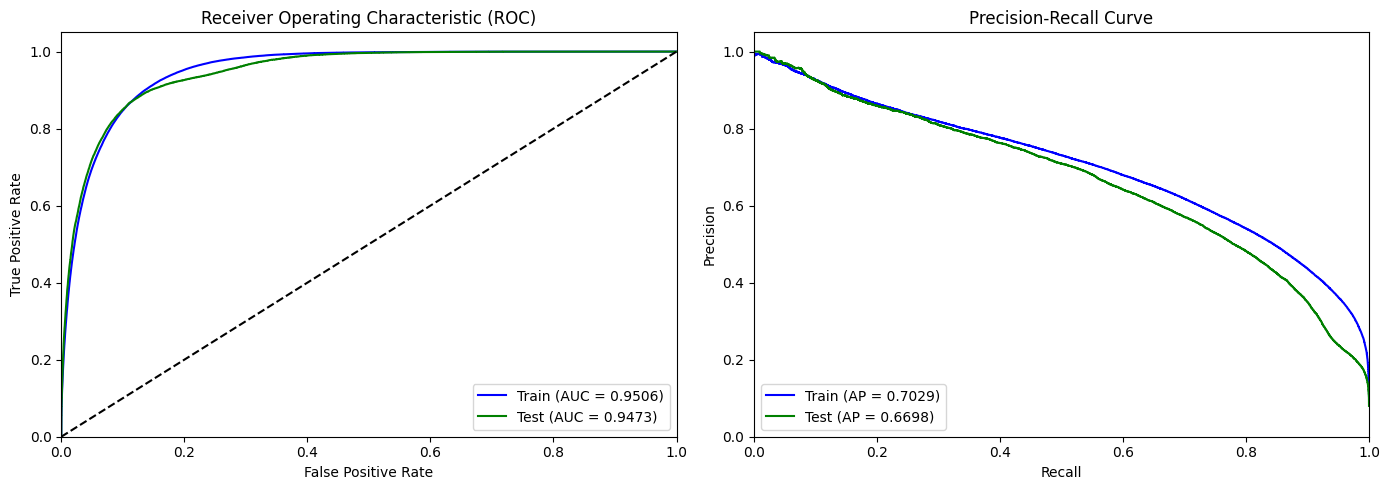

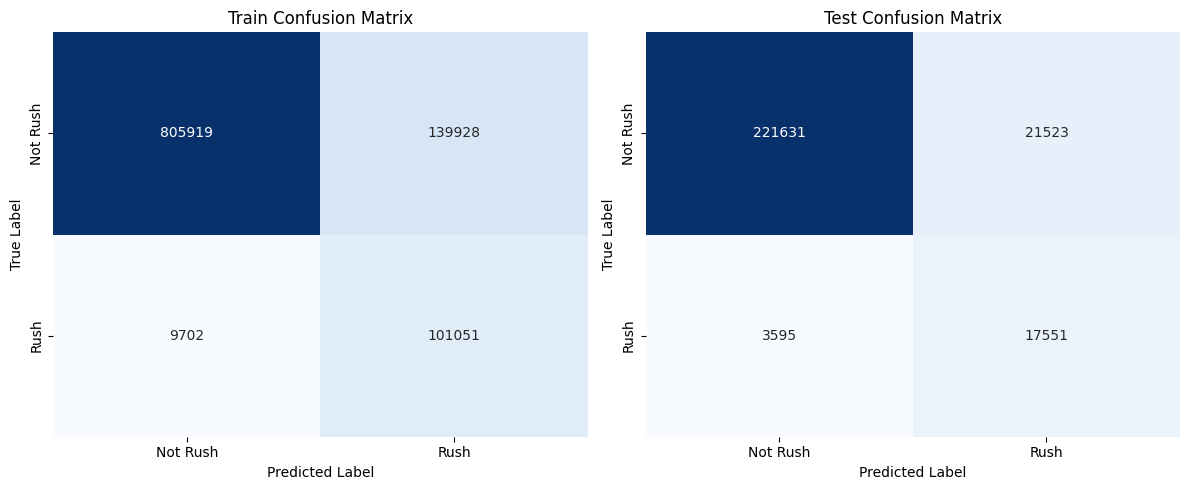

In [6]:
plot_logistic_metrics(RUSH_RESULT)
plot_confusion_matrix(RUSH_RESULT)


## Khối 6 · Dự đoán theo thời điểm do người dùng chọn

Người dùng tự chọn giờ cần dự đoán bằng cách sửa biến `DEMO_HOUR` trong cell code.

### 1) Bản đồ mật độ nhu cầu theo khu vực

`plot_area_folium(..., metric="total_demand")` cho biết khu vực nào có tổng nhu cầu cao.

### 2) Bản đồ xác suất rush tại thời điểm người dùng chọn

`DEMO_HOUR` nên nằm trong khoảng test được in ở `split_summary_table`.
Notebook sẽ hiển thị:
- bảng top khu vực có xác suất rush cao nhất;
- bản đồ `folium` xác suất rush tại đúng giờ đã chọn.


In [7]:
plot_area_folium(RUSH_LABELED, metric="total_demand")

DEMO_HOUR = pd.Timestamp("202-03-30 17:00:00")

show_top_rush_probabilities(RUSH_RESULT, timestamp_hour=DEMO_HOUR, top_n=15)
plot_rush_probability_map(RUSH_RESULT, timestamp_hour=DEMO_HOUR)


No records found for timestamp: 0202-03-30 17:00:00
No records found for timestamp: 0202-03-30 17:00:00
